<a href="https://colab.research.google.com/github/sathana495/DS_projects_01/blob/main/TN_Accident_prediction1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder
from sklearn.preprocessing import StandardScaler
sc=StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv(r'/content/drive/MyDrive/dataset/tamilnadu_accidents_dataset.csv')
df.head()

,Accident_ID,Date,Year,Month,Day_of_Week,Time_of_Day,District,Road_Type,Accident_Type,Primary_Cause,...,Helmet_Used,Seatbelt_Used,Road_Condition,Light_Condition,Weather_Condition,Junction_Type,Speed_Limit_kmph,Estimated_Speed_kmph,Alcohol_Involved,FIR_Filed
0,TN1001,2022-01-09,2022,1,Sunday,06:00-09:00,Cuddalore,State Highway,Rear-end Collision,Poor Road Condition,...,NaN,No,Good,Dark - No Light,Rainy,No Junction,80,20,No,Yes
1,TN1002,2019-06-09,2019,6,Sunday,06:00-09:00,Pudukkottai,National Highway,Rear-end Collision,Over Speeding,...,NaN,No,Potholed,Daylight,Windy,Roundabout,100,159,No,Yes
2,TN1003,2020-03-03,2020,3,Tuesday,00:00-03:00,Namakkal,Village Road,Rollover,Drunken Driving,...,Yes,NaN,Under Construction,Twilight,Foggy,Bridge,50,24,Yes,Yes
3,TN1004,2019-09-06,2019,9,Friday,12:00-15:00,Tirunelveli,City Road,Rollover,Hit and Run,...,NaN,NaN,Potholed,Dark - Street Lit,Clear,Four-Way Junction,50,40,No,Yes
4,TN1005,2024-08-05,2024,8,Monday,09:00-12:00,Dindigul,City Road,Hit Pedestrian,Aggressive/Rash Driving,...,NaN,NaN,Wet,Dark - No Light,Clear,T-Junction,30,24,No,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Accident_ID             600 non-null    object
 1   Date                    600 non-null    object
 2   Year                    600 non-null    int64 
 3   Month                   600 non-null    int64 
 4   Day_of_Week             600 non-null    object
 5   Time_of_Day             600 non-null    object
 6   District                600 non-null    object
 7   Road_Type               600 non-null    object
 8   Accident_Type           600 non-null    object
 9   Primary_Cause           600 non-null    object
 10  Vehicle_Type            600 non-null    object
 11  Severity                600 non-null    object
 12  Deaths                  600 non-null    int64 
 13  Grievous_Injuries       600 non-null    int64 
 14  Minor_Injuries          600 non-null    int64 
 15  Total_

In [ ]:
df.isnull().sum()

,0
Accident_ID,0
Date,0
Year,0
Month,0
Day_of_Week,0
Time_of_Day,0
District,0
Road_Type,0
Accident_Type,0
Primary_Cause,0


In [ ]:
df=df.drop(['Light_Condition','Junction_Type','Weather_Condition'],axis=1)

In [ ]:
df.columns

Index(['Accident_ID', 'Date', 'Year', 'Month', 'Day_of_Week', 'Time_of_Day',
       'District', 'Road_Type', 'Accident_Type', 'Primary_Cause',
       'Vehicle_Type', 'Severity', 'Deaths', 'Grievous_Injuries',
       'Minor_Injuries', 'Total_Persons_Involved', 'Victim_Age_Group',
       'Victim_Gender', 'Helmet_Used', 'Seatbelt_Used', 'Road_Condition',
       'Speed_Limit_kmph', 'Estimated_Speed_kmph', 'Alcohol_Involved',
       'FIR_Filed'],
      dtype='object')

In [ ]:
df['Helmet_Used']=df['Helmet_Used'].fillna(df['Helmet_Used'].mode()[0])
df['Seatbelt_Used']=df['Seatbelt_Used'].fillna(df['Seatbelt_Used'].mode()[0])

In [ ]:
df = pd.get_dummies(
    df,
    columns=[
        'Day_of_Week',
        'District',
        'Road_Type',
        'Accident_Type',
        'Primary_Cause',
        'Vehicle_Type',
        'Severity',
        'Victim_Age_Group',
        'Road_Condition'
    ],
    dtype='int64'
)

In [ ]:
print(df['Victim_Gender'].unique())

['Male' 'Female']


In [ ]:
print(df['Helmet_Used'].unique())


['No' 'Yes']


In [ ]:
print(df['Seatbelt_Used'].unique())

['No' 'Yes']


In [ ]:
print(df['Alcohol_Involved'].unique())

['No' 'Yes']


In [ ]:
print(df['FIR_Filed'].unique())

['Yes' 'No']


In [ ]:
df['Victim_Gender']=df['Victim_Gender'].map({'Male':1,'Female':0})
df['Helmet_Used']=df['Helmet_Used'].map({'Yes':1,'No':0})
df['Seatbelt_Used']=df['Seatbelt_Used'].map({'Yes':1,'No':0})
df['Alcohol_Involved']=df['Alcohol_Involved'].map({'Yes':1,'No':0})
df['FIR_Filed']=df['FIR_Filed'].map({'Yes':1,'No':0})


In [ ]:
df.head()

,Accident_ID,Date,Year,Month,Time_of_Day,Deaths,Grievous_Injuries,Minor_Injuries,Total_Persons_Involved,Victim_Gender,...,Victim_Age_Group_26-35,Victim_Age_Group_36-45,Victim_Age_Group_46-55,Victim_Age_Group_56-65,Victim_Age_Group_65+,Road_Condition_Dry,Road_Condition_Good,Road_Condition_Potholed,Road_Condition_Under Construction,Road_Condition_Wet
0,TN1001,2022-01-09,2022,1,06:00-09:00,0,1,0,1,1,...,0,0,0,0,0,0,1,0,0,0
1,TN1002,2019-06-09,2019,6,06:00-09:00,0,3,4,8,0,...,0,0,1,0,0,0,0,1,0,0
2,TN1003,2020-03-03,2020,3,00:00-03:00,0,0,4,5,1,...,1,0,0,0,0,0,0,0,1,0
3,TN1004,2019-09-06,2019,9,12:00-15:00,0,0,1,1,1,...,0,0,1,0,0,0,0,1,0,0
4,TN1005,2024-08-05,2024,8,09:00-12:00,0,0,4,6,1,...,1,0,0,0,0,0,0,0,0,1


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Day_of_Week'] = df['Date'].dt.dayofweek

df.drop('Date', axis=1, inplace=True)

In [ ]:
df.drop('Accident_ID', axis=1, inplace=True)

In [ ]:
df.drop('Time_of_Day',axis=1,inplace=True)

In [ ]:
df.head()

,Year,Month,Deaths,Grievous_Injuries,Minor_Injuries,Total_Persons_Involved,Victim_Gender,Helmet_Used,Seatbelt_Used,Speed_Limit_kmph,...,Victim_Age_Group_46-55,Victim_Age_Group_56-65,Victim_Age_Group_65+,Road_Condition_Dry,Road_Condition_Good,Road_Condition_Potholed,Road_Condition_Under Construction,Road_Condition_Wet,Day,Day_of_Week
0,2022,1,0,1,0,1,1,0,0,80,...,0,0,0,0,1,0,0,0,9,6
1,2019,6,0,3,4,8,0,0,0,100,...,1,0,0,0,0,1,0,0,9,6
2,2020,3,0,0,4,5,1,1,0,50,...,0,0,0,0,0,0,1,0,3,1
3,2019,9,0,0,1,1,1,0,0,50,...,1,0,0,0,0,1,0,0,6,4
4,2024,8,0,0,4,6,1,0,0,30,...,0,0,0,0,0,0,0,1,5,0


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['Year'] = scaler.fit_transform(df[['Year']])

In [ ]:
df.head(3)

,Year,Month,Deaths,Grievous_Injuries,Minor_Injuries,Total_Persons_Involved,Victim_Gender,Helmet_Used,Seatbelt_Used,Speed_Limit_kmph,...,Victim_Age_Group_46-55,Victim_Age_Group_56-65,Victim_Age_Group_65+,Road_Condition_Dry,Road_Condition_Good,Road_Condition_Potholed,Road_Condition_Under Construction,Road_Condition_Wet,Day,Day_of_Week
0,0.482281,1,0,1,0,1,1,0,0,80,...,0,0,0,0,1,0,0,0,9,6
1,-1.030098,6,0,3,4,8,0,0,0,100,...,1,0,0,0,0,1,0,0,9,6
2,-0.525972,3,0,0,4,5,1,1,0,50,...,0,0,0,0,0,0,1,0,3,1


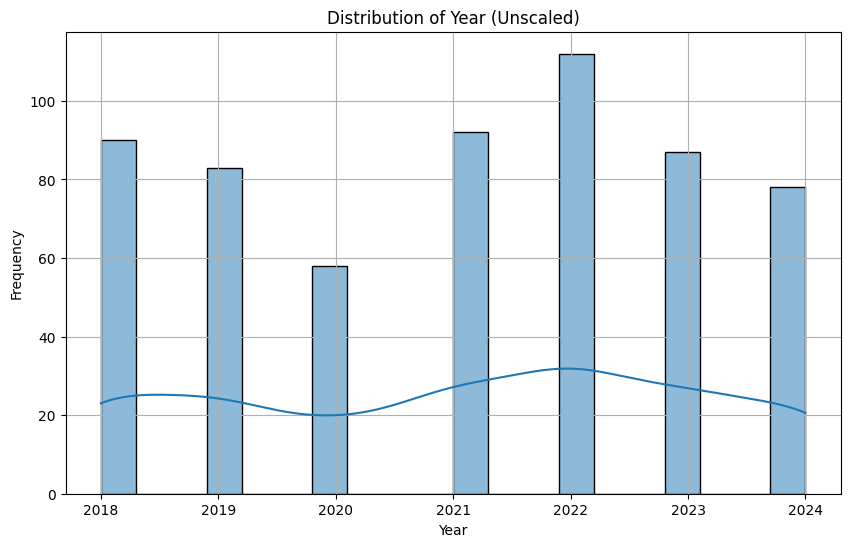

In [ ]:
import pandas as pd

# Create a temporary dataframe to get the original 'Year' for plotting
temp_df = pd.read_csv(r'/content/drive/MyDrive/dataset/tamilnadu_accidents_dataset.csv')

plt.figure(figsize=(10, 6))
sns.histplot(temp_df['Year'], bins=20, kde=True)
plt.title('Distribution of Year (Unscaled)')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Delete the temporary dataframe to free memory
del temp_df

/tmp/ipykernel_1190/1896960289.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Year', y='Deaths', data=deaths_per_year, palette='viridis')


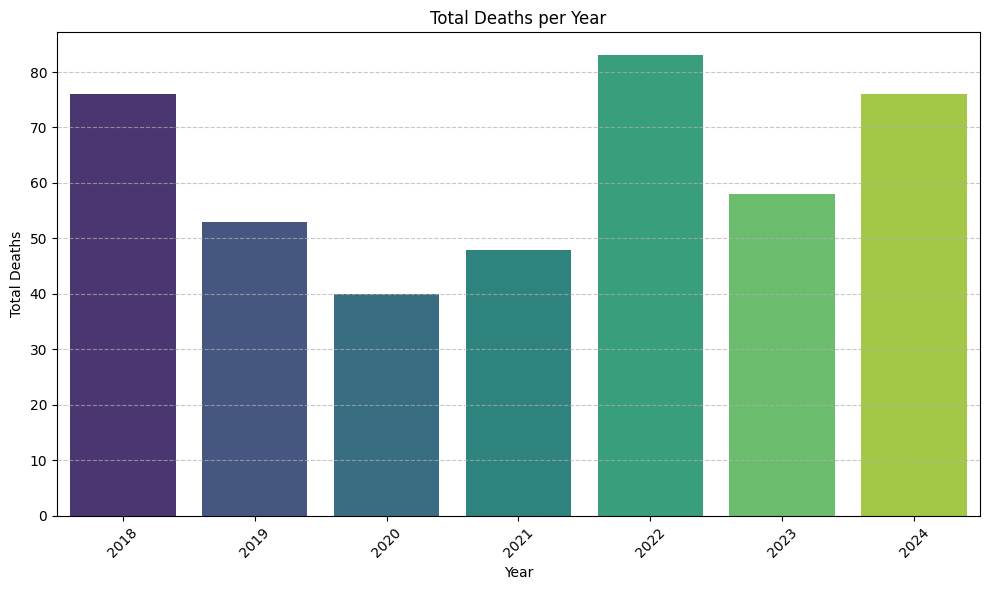

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a temporary dataframe to get the original 'Year' and 'Deaths' for plotting
temp_df = pd.read_csv(r'/content/drive/MyDrive/dataset/tamilnadu_accidents_dataset.csv')

# Group by Year and sum the Deaths
deaths_per_year = temp_df.groupby('Year')['Deaths'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Year', y='Deaths', data=deaths_per_year, palette='viridis')
plt.title('Total Deaths per Year')
plt.xlabel('Year')
plt.ylabel('Total Deaths')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Delete the temporary dataframe to free memory
del temp_df

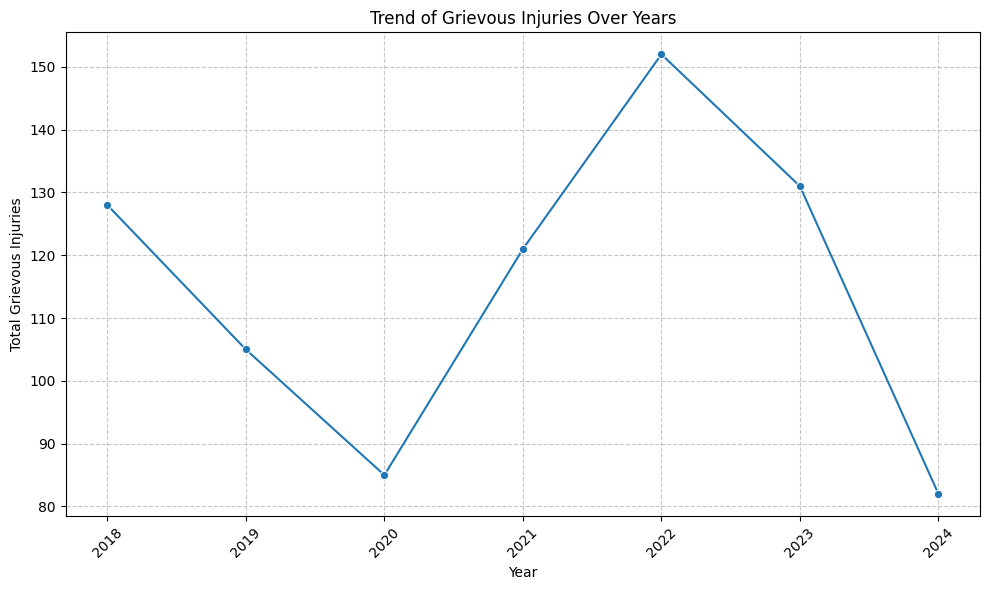

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a temporary dataframe to get the original 'Year' and 'Grievous_Injuries' for plotting
temp_df = pd.read_csv(r'/content/drive/MyDrive/dataset/tamilnadu_accidents_dataset.csv')

# Group by Year and sum the Grievous_Injuries
grievous_injuries_per_year = temp_df.groupby('Year')['Grievous_Injuries'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x='Year', y='Grievous_Injuries', data=grievous_injuries_per_year, marker='o')
plt.title('Trend of Grievous Injuries Over Years')
plt.xlabel('Year')
plt.ylabel('Total Grievous Injuries')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Delete the temporary dataframe to free memory
del temp_df

*Step 1: Separate Features and Target*

In [ ]:
X = df.drop('Deaths', axis=1)
y = df['Deaths']

In [ ]:
df['Deaths'].value_counts()

,count
Deaths,
0,433
2,46
4,45
3,43
1,33


*Train-Test Split*

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)


In [ ]:
import joblib

model=joblib.dump(rf, 'accident_prediction_model.pkl')
print(model)

['accident_prediction_model.pkl']


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

Accuracy=accuracy_score(y_test, y_pred)
print(Accuracy*100)
print(classification_report(y_test, y_pred))

84.16666666666667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       1.00      0.43      0.60         7
           2       0.36      0.56      0.43         9
           3       0.25      0.25      0.25         8
           4       0.50      0.44      0.47         9

    accuracy                           0.84       120
   macro avg       0.62      0.54      0.55       120
weighted avg       0.86      0.84      0.84       120

